In [43]:
# Run data_processing.py to load and prepare all data, variables, and helper functions.


import importlib

# Dynamically import the module
data_processing = importlib.import_module("01_data_processing")


# Since you were using 'import *', you can pull everything into the global namespace like this:
globals().update(vars(data_processing))

import matplotlib.pyplot as plt
import seaborn as sns
import os
output_dir = os.path.join('..', 'output')

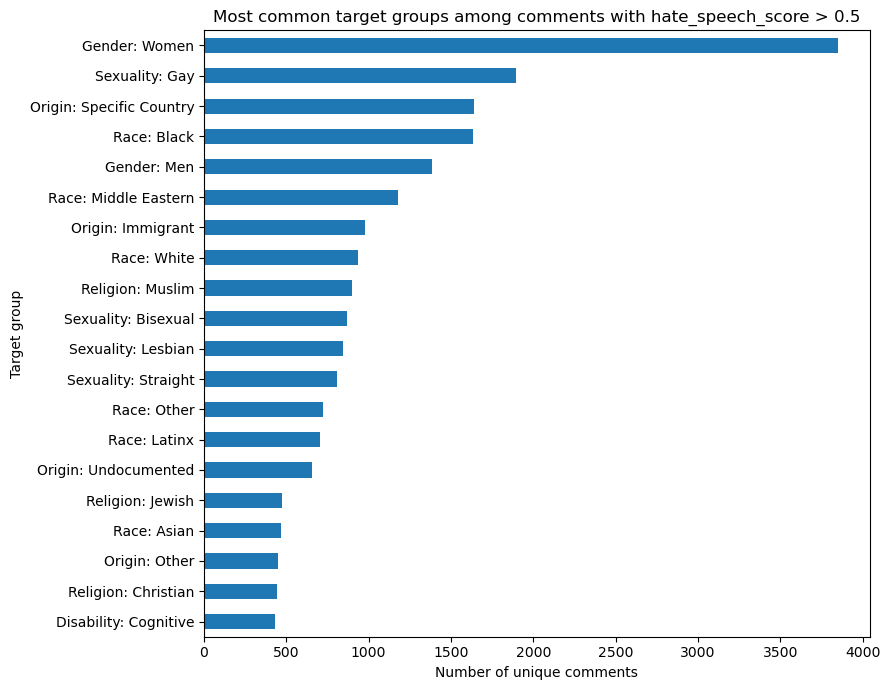

In [44]:
# Most common target groups
top_n = 20

plot_df = summary.nlargest(top_n, "n_comments").sort_values("n_comments")

ax = plot_df.plot(
    x="target_clean",
    y="n_comments",
    kind="barh",
    figsize=(9, 7),
    legend=False
)

ax.set_title(f"Most common target groups among comments with hate_speech_score > {HATE_THRESHOLD}")
ax.set_xlabel("Number of unique comments")
ax.set_ylabel("Target group")
plt.tight_layout()
fig_path = os.path.join(output_dir, 'most_common_target_groups.png')
plt.savefig(fig_path)
plt.show()

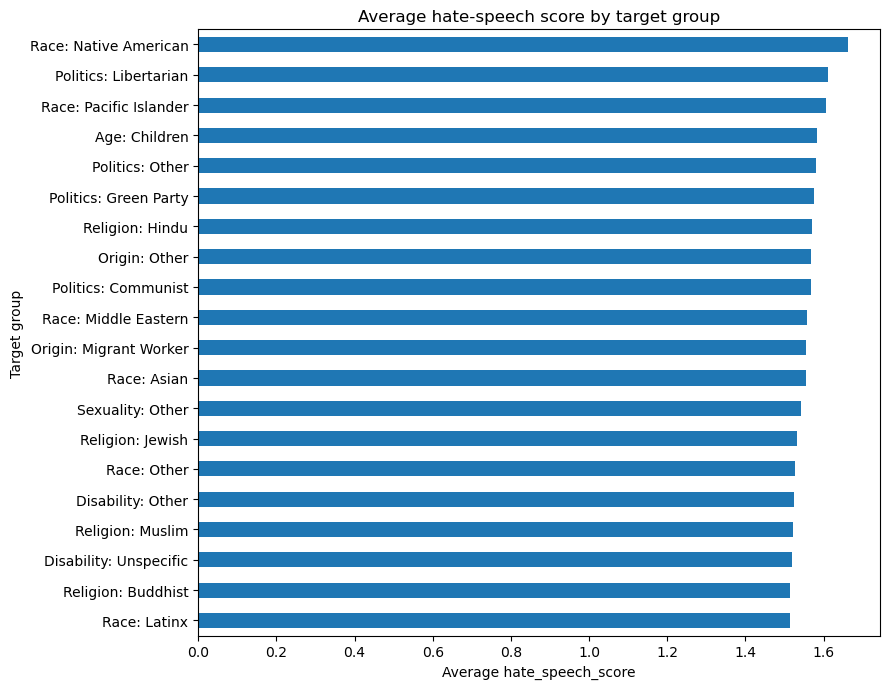

In [45]:
# Average hate-speech score by target group
plot_df = summary.nlargest(top_n, "avg_hate_score").sort_values("avg_hate_score")

ax = plot_df.plot(
    x="target_clean",
    y="avg_hate_score",
    kind="barh",
    figsize=(9, 7),
    legend=False
)

ax.set_title("Average hate-speech score by target group")
ax.set_xlabel("Average hate_speech_score")
ax.set_ylabel("Target group")
plt.tight_layout()
fig_path = os.path.join(output_dir, 'avg_hs_score.png')
plt.savefig(fig_path)
plt.show()

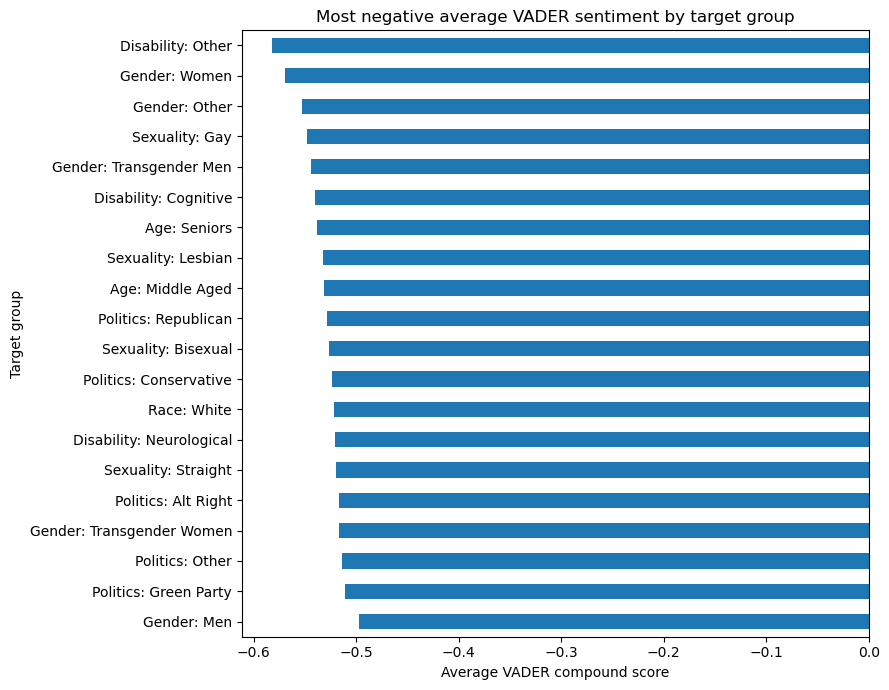

In [46]:
# Most negative average VADER sentiment by target group
plot_df = summary.nsmallest(top_n, "avg_vader_compound").sort_values("avg_vader_compound", ascending=False)

ax = plot_df.plot(
    x="target_clean",
    y="avg_vader_compound",
    kind="barh",
    figsize=(9, 7),
    legend=False
)

ax.set_title("Most negative average VADER sentiment by target group")
ax.set_xlabel("Average VADER compound score")
ax.set_ylabel("Target group")

plt.tight_layout()
fig_path = os.path.join(output_dir, 'avg_vader_score.png')
plt.savefig(fig_path)
plt.show()

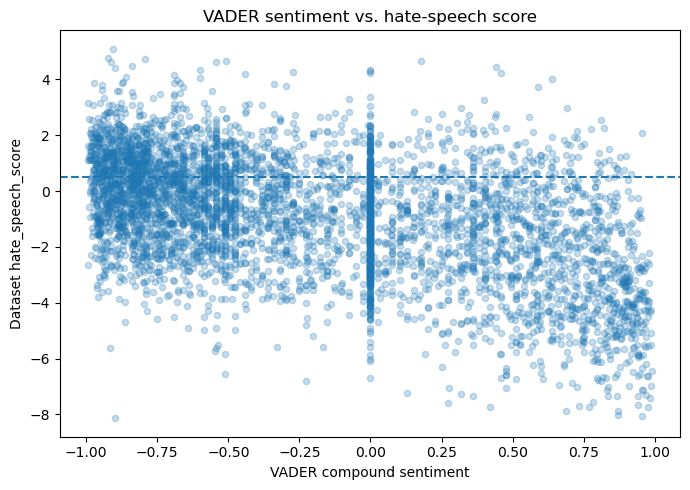

In [47]:
# VADER sentiment vs. hate-speech score scatter
ax = sample.plot(
    x="vader_compound",
    y="hate_speech_score",
    kind="scatter",
    alpha=0.25,
    figsize=(7, 5)
)

ax.axhline(HATE_THRESHOLD, linestyle="--")
ax.set_title("VADER sentiment vs. hate-speech score")
ax.set_xlabel("VADER compound sentiment")
ax.set_ylabel("Dataset hate_speech_score")
plt.tight_layout()
fig_path = os.path.join(output_dir, 'vader_v_hs_scores.png')
plt.savefig(fig_path)
plt.show()

In [48]:


# Prepare values and colormap for gradient
subset_for_gradient = [col for col in WORDS_TO_SEARCH if col in word_rates.columns]

if subset_for_gradient:
    # Ensure gradient values are numeric; fill NaNs with 0 for min/max calculation
    gradient_data = word_rates[subset_for_gradient].apply(pd.to_numeric, errors='coerce').fillna(0)
    vmin = gradient_data.min().min()
    vmax = gradient_data.max().max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.get_cmap("Reds")
else:
    # Fallback if no columns for gradient are found
    norm = plt.Normalize(vmin=0, vmax=1)
    cmap = plt.cm.get_cmap("Greys") # Neutral colormap

# Create the figure and axes
# Dynamically size the figure based on DataFrame dimensions for better readability
fig, ax = plt.subplots(figsize=(word_rates.shape[1] * 1.5, word_rates.shape[0] * 0.4))
ax.axis('off') # Hide axes

# Prepare cell colors and text for the Matplotlib table
cell_colors = []
cell_text = []

for idx, row in word_rates.iterrows():
    row_colors = []
    row_text = []
    for col_name in word_rates.columns:
        value = row[col_name]

        # Format text based on column type
        if col_name in WORDS_TO_SEARCH:
            text = f"{value:.1f}" if pd.notna(value) else ""
        elif col_name == "n_comments":
            text = f"{value:.0f}" if pd.notna(value) else ""
        else:
            text = str(value) if pd.notna(value) else ""
        row_text.append(text)

        # Determine cell color for gradient columns
        if col_name in subset_for_gradient and pd.notna(value):
            color = cmap(norm(value))
        else:
            color = 'white' # Default background for non-gradient columns
        row_colors.append(color)
    cell_colors.append(row_colors)
    cell_text.append(row_text)

# Create the table using Matplotlib
table = ax.table(cellText=cell_text,
                 colLabels=word_rates.columns,
                 rowLabels=word_rates.index,
                 cellLoc='center', loc='center',
                 cellColours=cell_colors)

table.auto_set_font_size(False)
table.set_fontsize(8) # Adjust font size as needed
table.scale(1.2, 1.2) # Adjust scale for better cell padding

# Set title for the plot
ax.set_title('Word Rate Heatmap Table', fontsize=14)

plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Save the figure as a PNG
png_path = os.path.join(output_dir, 'searched_word_matrix.png')
plt.savefig(png_path, bbox_inches='tight', dpi=300) # bbox_inches='tight' to prevent clipping
plt.close(fig) # Close the figure to free memory

print(f"Heatmap table saved to: {png_path}")


Heatmap table saved to: ../output/searched_word_matrix.png


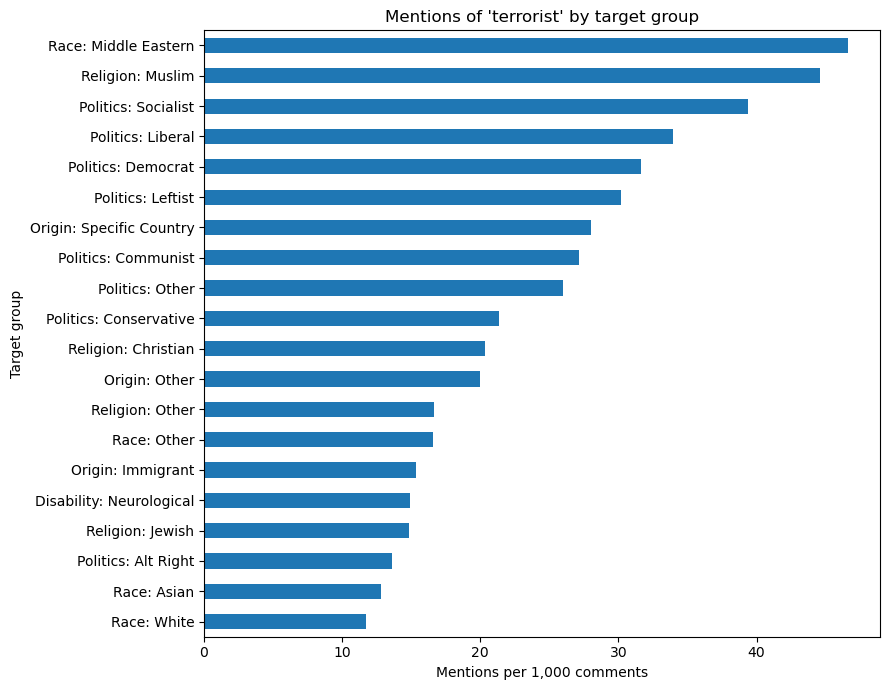

In [49]:
# Mentions of a single term by target group
TERM_TO_PLOT = "terrorist"

if TERM_TO_PLOT not in word_rates.columns:
    word_rates = word_rate_table(analysis, [TERM_TO_PLOT], min_comments=MIN_COMMENTS_PER_TARGET)

plot_df = word_rates.sort_values(TERM_TO_PLOT).tail(20)

ax = plot_df[TERM_TO_PLOT].plot(kind="barh", figsize=(9, 7))
ax.set_title(f"Mentions of '{TERM_TO_PLOT}' by target group")
ax.set_xlabel("Mentions per 1,000 comments")
ax.set_ylabel("Target group")
plt.tight_layout()
fig_path = os.path.join(output_dir, 'plot_term_terrorist.png')
plt.savefig(fig_path)
plt.show()

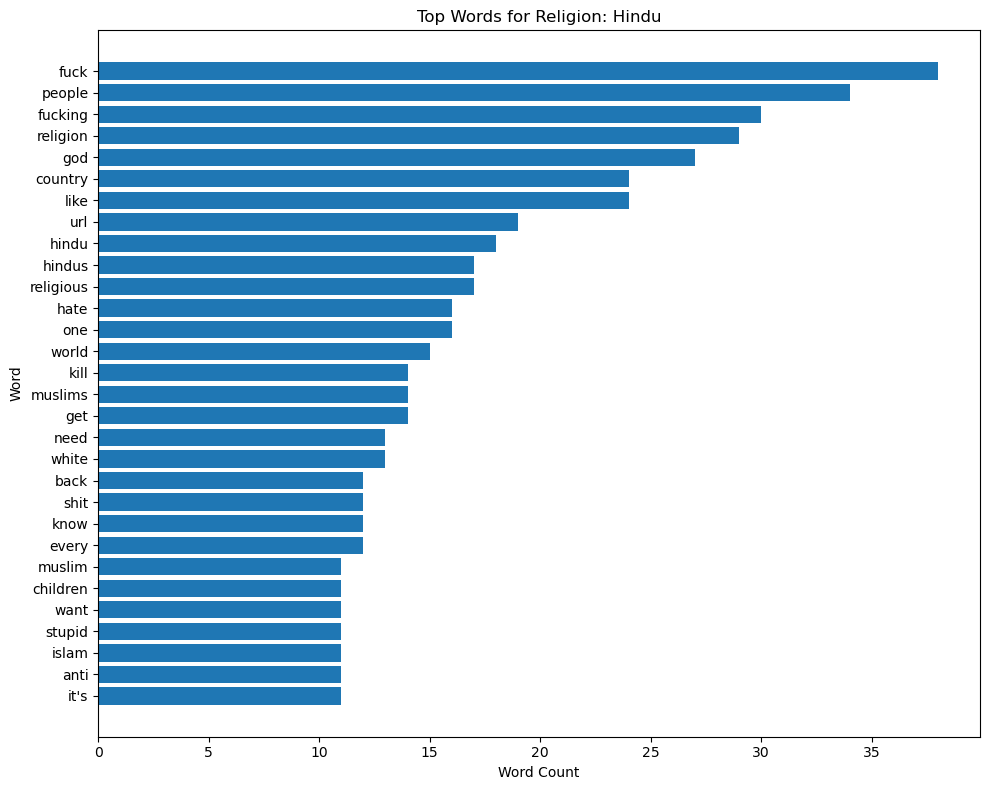

In [35]:
# Top words for a specific target group
top_words_df = top_words_for_target(hate, TARGET_TO_INSPECT, n=30)

plt.figure(figsize=(10, 8))
plt.barh(top_words_df['word'], top_words_df['count'])
plt.gca().invert_yaxis()
plt.title(f'Top Words for {TARGET_TO_INSPECT}')
plt.xlabel('Word Count')
plt.ylabel('Word')
plt.tight_layout()
fig_path = os.path.join(output_dir, 'target_words_hindu.png')
plt.savefig(fig_path)
plt.show()

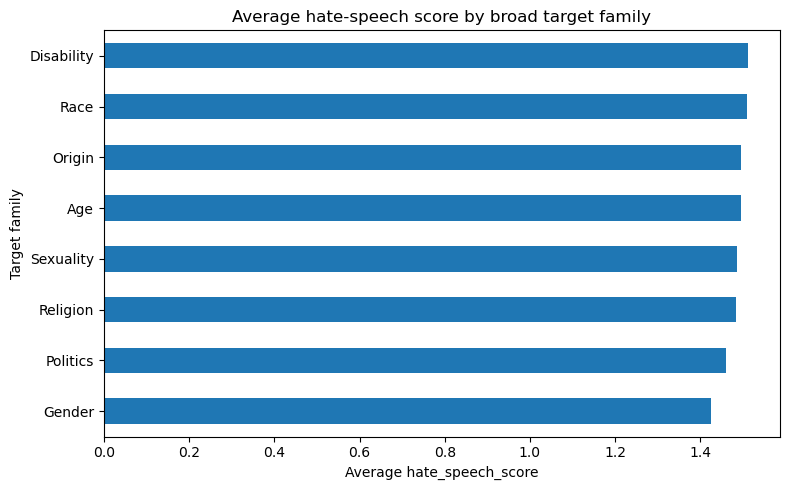

In [36]:
# Average hate-speech score by broad target family
ax = family_summary["avg_hate_score"].sort_values().plot(kind="barh", figsize=(8, 5))
ax.set_title("Average hate-speech score by broad target family")
ax.set_xlabel("Average hate_speech_score")
ax.set_ylabel("Target family")
plt.tight_layout()
plt.show()

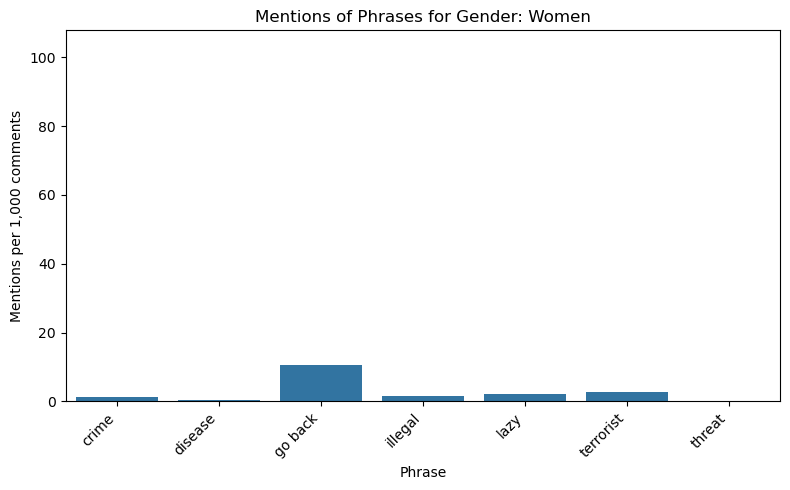

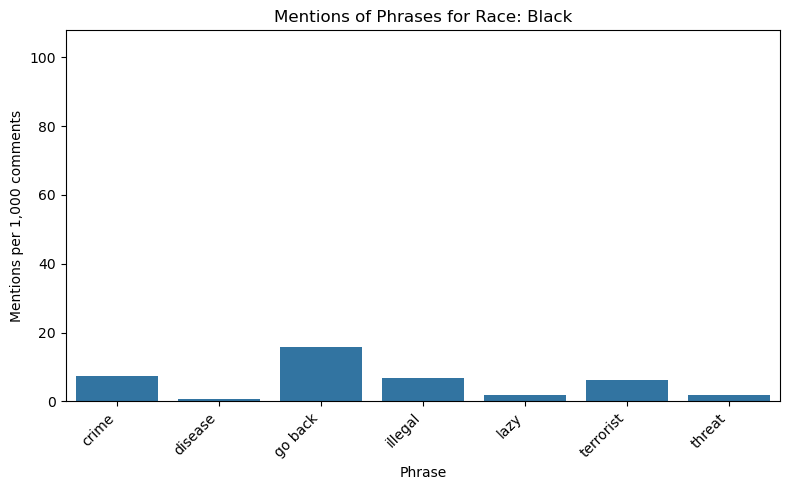

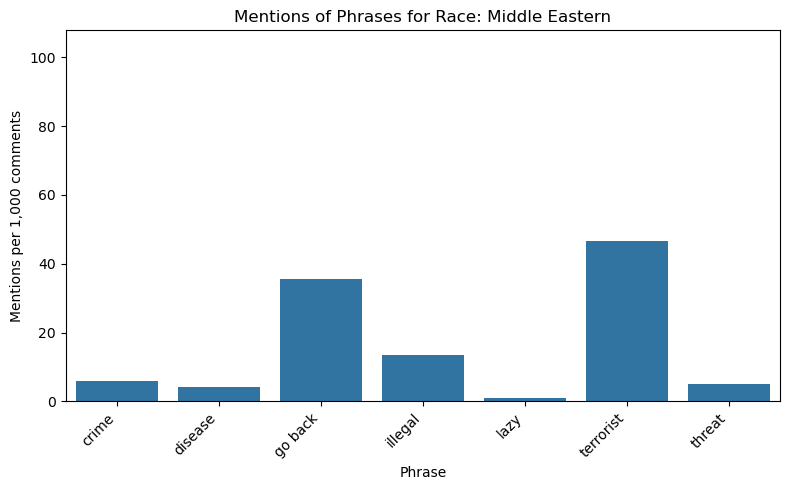

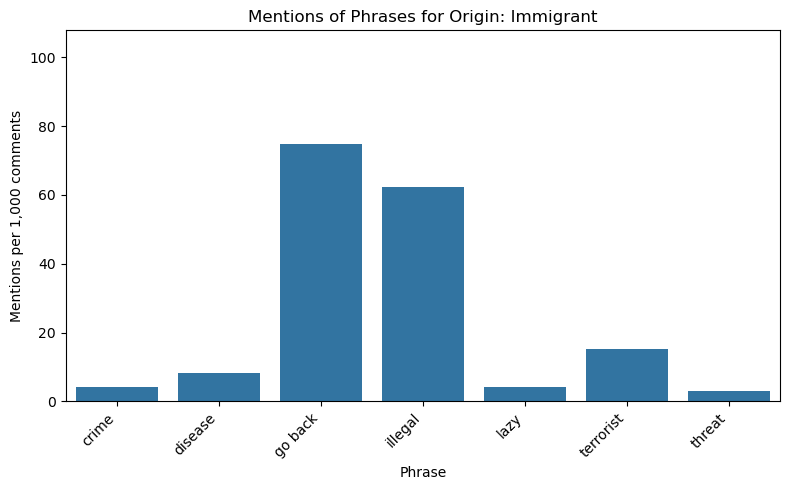

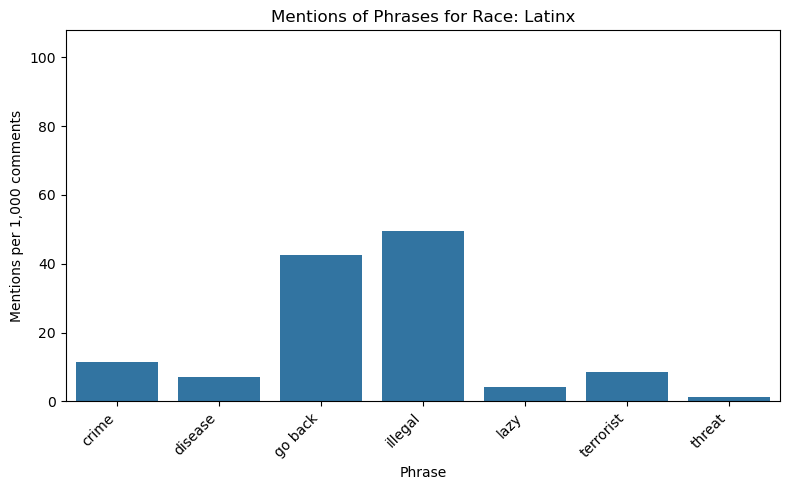

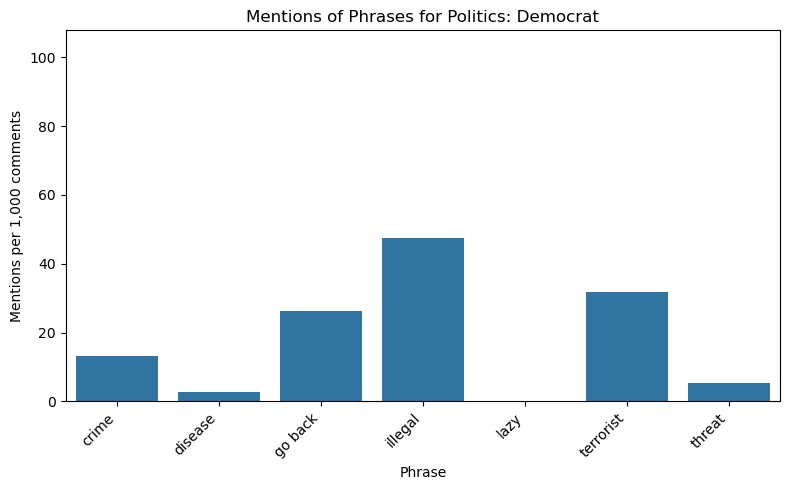

In [37]:
# Per-target phrase mention rates for selected groups
target_groups_to_plot = [
    'Gender: Women',
    'Race: Black',
    'Race: Middle Eastern',
    'Origin: Immigrant',
    'Race: Latinx',
    'Politics: Democrat'
]

if not all(word in word_rates.columns for word in WORDS_TO_SEARCH):
    word_rates = word_rate_table(analysis, WORDS_TO_SEARCH, min_comments=MIN_COMMENTS_PER_TARGET)

max_y_value = word_rates[WORDS_TO_SEARCH].values.max()

for target in target_groups_to_plot:
    if target in word_rates.index:
        plot_data = word_rates.loc[target, WORDS_TO_SEARCH].sort_index()

        plt.figure(figsize=(8, 5))
        sns.barplot(x=plot_data.index, y=plot_data.values)
        plt.title(f'Mentions of Phrases for {target}')
        plt.xlabel('Phrase')
        plt.ylabel('Mentions per 1,000 comments')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, max_y_value * 1.1)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: Target group '{target}' not found in word_rates. Skipping plot.")

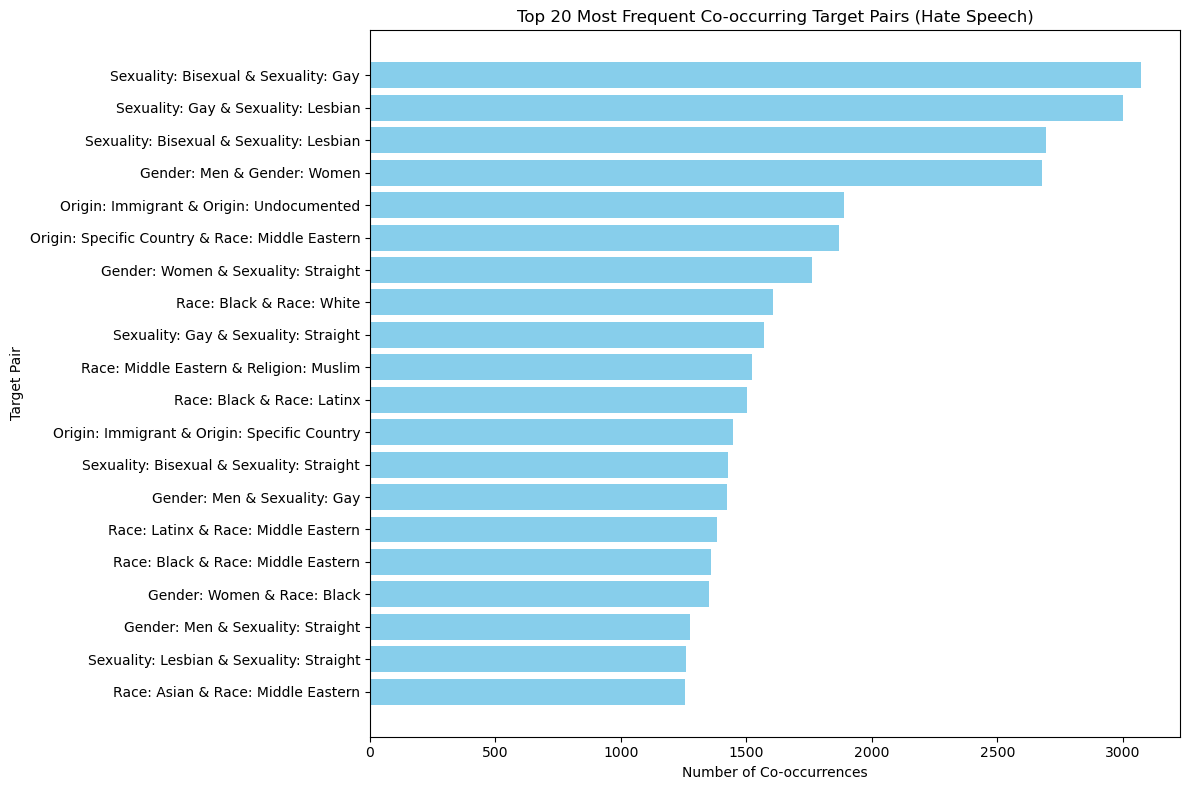

In [38]:
# Co-occurring target pairs: bar chart of top 20
plot_co_occurrence_df = co_occurrence_df.head(20).copy()
plot_co_occurrence_df['pair_label'] = plot_co_occurrence_df.apply(
    lambda row: f"{row['target_1']} & {row['target_2']}", axis=1
)
plot_co_occurrence_df = plot_co_occurrence_df.sort_values('count', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(plot_co_occurrence_df['pair_label'], plot_co_occurrence_df['count'], color='skyblue')
plt.title('Top 20 Most Frequent Co-occurring Target Pairs (Hate Speech)')
plt.xlabel('Number of Co-occurrences')
plt.ylabel('Target Pair')
plt.tight_layout()
fig_path = os.path.join(output_dir, 'common_pairs.png')
plt.savefig(fig_path)

plt.show()

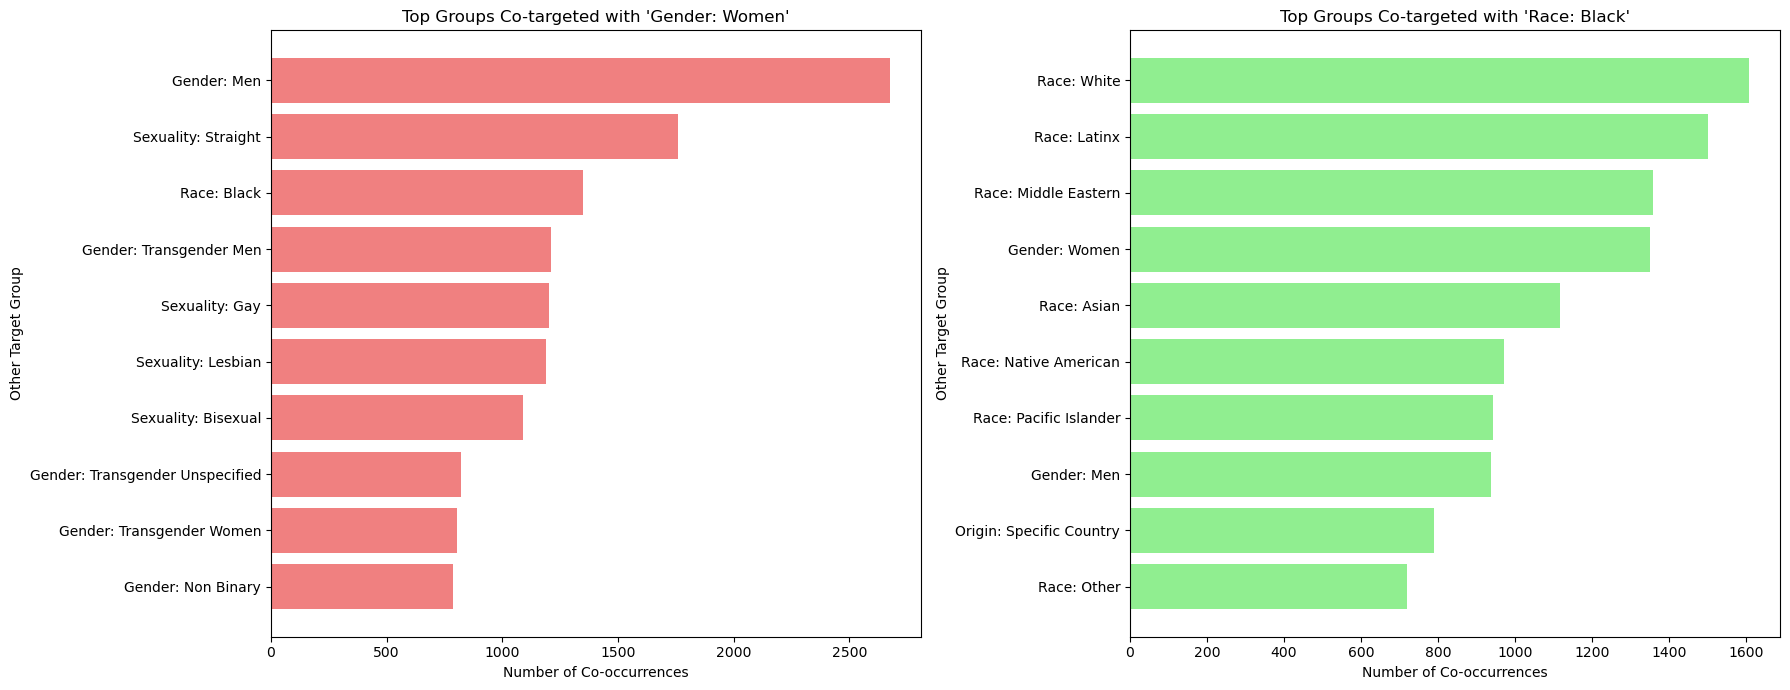

In [39]:
# Co-targeted groups for 'Gender: Women' and 'Race: Black'
gen_women_co_targets = get_co_targeted_groups(co_occurrence_df, 'Gender: Women').reset_index()
gen_women_co_targets.columns = ['other_target', 'count']

race_black_co_targets = get_co_targeted_groups(co_occurrence_df, 'Race: Black').reset_index()
race_black_co_targets.columns = ['other_target', 'count']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

gen_women_co_targets_sorted = gen_women_co_targets.sort_values('count', ascending=True)
axes[0].barh(gen_women_co_targets_sorted['other_target'], gen_women_co_targets_sorted['count'], color='lightcoral')
axes[0].set_title("Top Groups Co-targeted with 'Gender: Women'")
axes[0].set_xlabel('Number of Co-occurrences')
axes[0].set_ylabel('Other Target Group')

race_black_co_targets_sorted = race_black_co_targets.sort_values('count', ascending=True)
axes[1].barh(race_black_co_targets_sorted['other_target'], race_black_co_targets_sorted['count'], color='lightgreen')
axes[1].set_title("Top Groups Co-targeted with 'Race: Black'")
axes[1].set_xlabel('Number of Co-occurrences')
axes[1].set_ylabel('Other Target Group')

plt.tight_layout()

fig_path = os.path.join(output_dir, 'women_black_co_targets.png')
plt.savefig(fig_path)
plt.show()

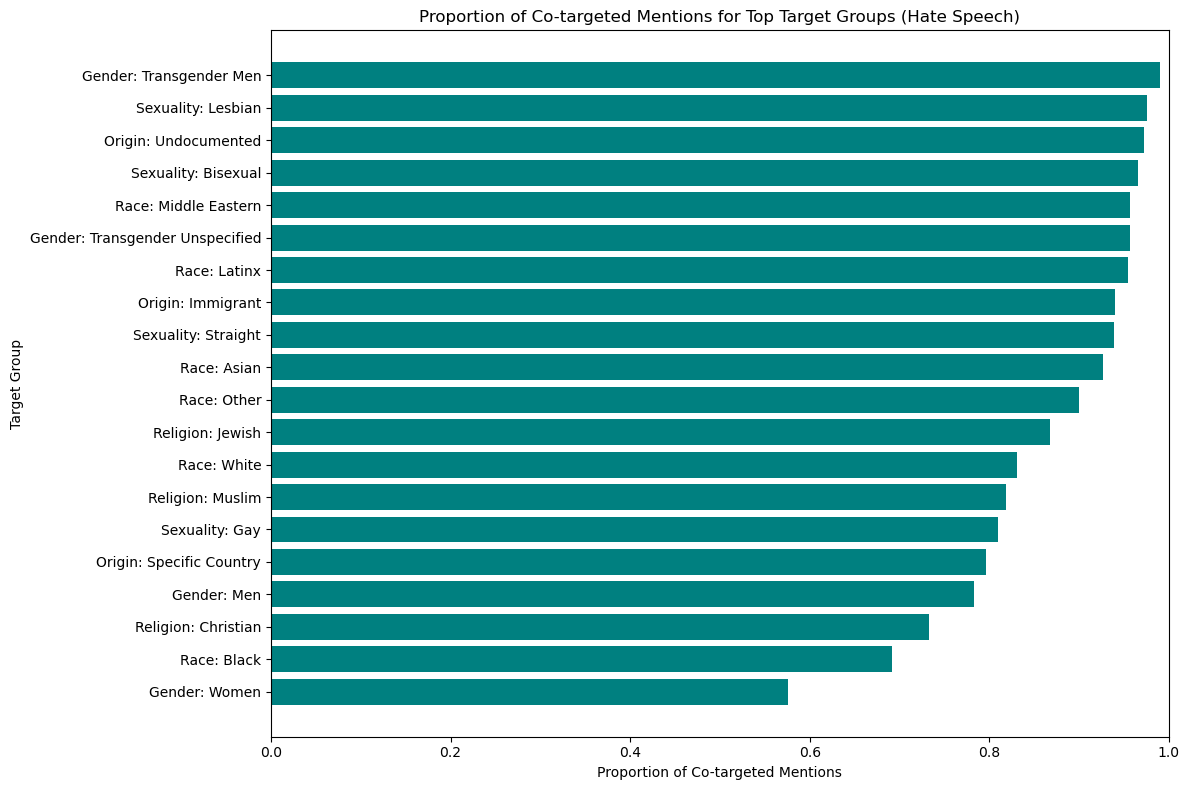

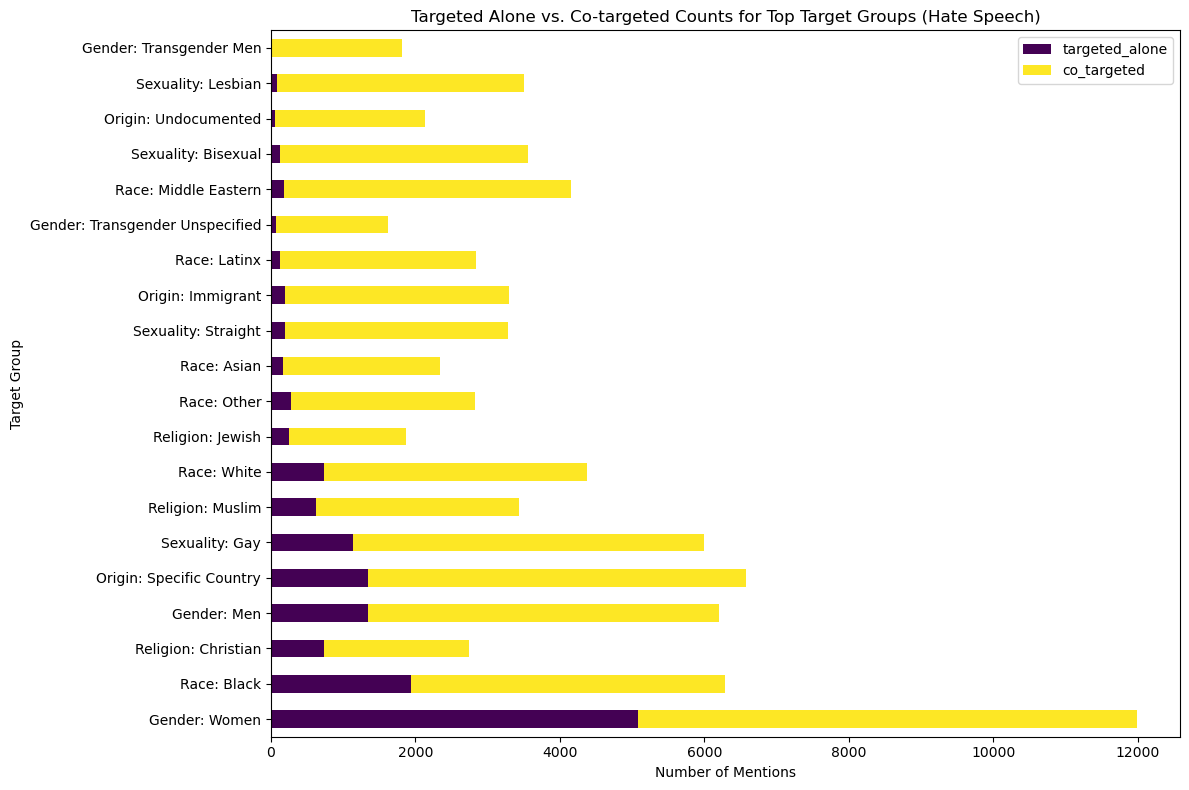

In [40]:
# Proportion of co-targeted mentions for top target groups
plot_df = targeting_summary.nlargest(20, 'total_mentions').sort_values('proportion_co_targeted', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(
    plot_df.index,
    plot_df['proportion_co_targeted'],
    color='teal'
)
plt.title('Proportion of Co-targeted Mentions for Top Target Groups (Hate Speech)')
plt.xlabel('Proportion of Co-targeted Mentions')
plt.ylabel('Target Group')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plot_df[['targeted_alone', 'co_targeted']].plot(kind='barh', stacked=True, figsize=(12, 8), colormap='viridis')
plt.title('Targeted Alone vs. Co-targeted Counts for Top Target Groups (Hate Speech)')
plt.xlabel('Number of Mentions')
plt.ylabel('Target Group')
plt.tight_layout()
fig_path = os.path.join(output_dir, 'co_target_proportions.png')
plt.savefig(fig_path)
plt.show()

In [50]:
print(len(comments))                          # total unique comments
print(comments["hate_speech_score"].describe()) # score range/mean
print(len(target_long))                        # total comment x target rows
print(hate["comment_id"].nunique())            # comments flagged as hate speech
print(target_long["target_clean"].nunique())   # number of unique target groups
print(hate["target_clean"].nunique())          # target groups with 50+ comments

39565
count    39565.000000
mean        -0.943911
std          2.073087
min         -8.340000
25%         -2.330000
50%         -0.700000
75%          0.570000
max          6.300000
Name: hate_speech_score, dtype: float64
109280
10354
57
57


In [51]:
print(comments["hate_speech_score"].min(), comments["hate_speech_score"].max())
print((comments["hate_speech_score"] > 0.5).sum())

-8.34 6.3
10354
